<a href="https://colab.research.google.com/github/RenataH02/Computer_Vision_Project/blob/main/stage2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Project Stage 2: Flow Matching to Class Prototypes

**Builds on Stage 1.** Same datasets (DTD + Oxford Flowers-102), same frozen encoders (ResNet-18 on
both, DINOv2 on Flowers), same class prototypes, same K &isin; {5, 10, full} training subsets and seeds,
same test sets. This adds a flow matching layer on top of the Stage 1 prototype baseline
and compares:

- the **Stage 1 prototype baseline**
- **standard FM** training, evaluated with T = 4 and T = 12 inference steps
- **rolled-out FM** training, trained and evaluated with the *same* T &isin; {4, 12}

### Design choice: FM operates in L2-normalized feature space

Stage 1's prototypes are **unit norm** (classification is by cosine similarity), but the raw frozen
features are not. If FM transported *raw* features toward unit norm prototypes, the network would also
have to learn a large, uninteresting rescaling on top of the actual class discriminative transport. We
therefore L2-normalize every feature (train and test) before it enters the FM layer, so the source and
target live on a comparable scale — the same space Stage 1's cosine classifier already uses.


This reuses the **same `features/` cache** produced for Stage 1 (`<dataset>_<encoder>_<split>.npz`).

---
# Part 1 — Load the Stage 1 feature cache

In [ ]:
import shutil, sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
ROOT = Path.cwd()
FEATURES_DIR = ROOT / 'features'
REQUIRED = [('dtd', 'resnet18'), ('flowers102', 'resnet18'), ('flowers102', 'dinov2')]
SPLITS = ('train', 'val', 'test')

def caches_present(base=None):
    base = base or FEATURES_DIR
    return all((base / f'{ds}_{enc}_{sp}.npz').exists() for ds, enc in REQUIRED for sp in SPLITS)

if not caches_present() and IN_COLAB:
    from google.colab import files
    print('features/ not found — select your features.zip')
    uploaded = files.upload()
    for name in uploaded:
        shutil.unpack_archive(name, str(FEATURES_DIR))
    nested = FEATURES_DIR / 'features'
    if nested.is_dir():
        for item in nested.iterdir():
            shutil.move(str(item), str(FEATURES_DIR / item.name))
        nested.rmdir()

print('all caches present:', caches_present())

features/ not found — select your features.zip


Saving features.zip to features.zip
all caches present: True


---
# Part 2 — Config and Stage 1 helper functions

Identical to Stage 1: same `DATASETS`/`ENCODERS` config, same seeds, same balanced subset sampling,
same prototype computation.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

DATASETS = {
    'dtd': {'name': 'DTD', 'num_classes': 47, 'encoders': ['resnet18']},
    'flowers102': {'name': 'Oxford Flowers-102', 'num_classes': 102,
                   'encoders': ['resnet18', 'dinov2']},
}
ENCODERS = {
    'resnet18': {'name': 'ImageNet-1K ResNet-18', 'dim': 512},
    'dinov2': {'name': 'DINOv2 ViT-S/14', 'dim': 384},
}

K_VALUES = [5, 10, 'full']
SUBSET_SEEDS = [0, 1, 2]
INIT_SEEDS = [0, 1, 2]


def load_features(ds, enc, split):
    d = np.load(FEATURES_DIR / f'{ds}_{enc}_{split}.npz')
    return d['features'].astype(np.float32), d['labels'].astype(np.int64)


def load_class_names(ds):
    p = FEATURES_DIR / f'{ds}_classes.json'
    return json.loads(p.read_text(encoding='utf-8')) if p.exists() else None


def sample_balanced_subset(labels, k, seed):
    rng = np.random.default_rng(seed)
    chosen = []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        chosen.append(idx if idx.size <= k else rng.choice(idx, size=k, replace=False))
    return np.sort(np.concatenate(chosen))


def resolve_train_indices(labels, k, seed):
    if k == 'full':
        return np.arange(len(labels))
    return sample_balanced_subset(labels, int(k), seed)


def top1_accuracy(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


def l2_normalize(x, axis=-1, eps=1e-12):
    return x / (np.linalg.norm(x, axis=axis, keepdims=True) + eps)


def compute_prototypes(X, y, num_classes):
    Xn = l2_normalize(np.asarray(X, dtype=np.float64), axis=1)
    protos = np.zeros((num_classes, Xn.shape[1]))
    for c in range(num_classes):
        m = y == c
        if np.any(m):
            protos[c] = Xn[m].mean(axis=0)
    return l2_normalize(protos, axis=1)


def prototype_classify(X, prototypes):
    return (l2_normalize(np.asarray(X, dtype=np.float64), axis=1) @ prototypes.T).argmax(axis=1)

print('config and Stage 1 helpers ready')

config and Stage 1 helpers ready



# Part 3 — Recompute the Stage 1 prototype baseline


In [ ]:
baseline_results = {}

for ds, cfg in DATASETS.items():
    C = cfg['num_classes']
    baseline_results[ds] = {}
    for enc in cfg['encoders']:
        Xtr, ytr = load_features(ds, enc, 'train')
        Xte, yte = load_features(ds, enc, 'test')
        baseline_results[ds][enc] = {}
        for k in K_VALUES:
            seeds = INIT_SEEDS[:1] if k == 'full' else SUBSET_SEEDS
            accs = []
            for seed in seeds:
                tr_idx = resolve_train_indices(ytr, k, seed)
                protos = compute_prototypes(Xtr[tr_idx], ytr[tr_idx], C)
                accs.append(top1_accuracy(yte, prototype_classify(Xte, protos)))
            baseline_results[ds][enc][str(k)] = {'runs': accs, 'mean': float(np.mean(accs)), 'std': float(np.std(accs))}

for ds, cfg in DATASETS.items():
    for enc in cfg['encoders']:
        line = '  '.join(f"K={k}: {100*baseline_results[ds][enc][str(k)]['mean']:.2f}" for k in K_VALUES)
        print(f"{cfg['name']:20s} {enc:9s}  {line}")

DTD                  resnet18   K=5: 46.51  K=10: 53.37  K=full: 58.78
Oxford Flowers-102   resnet18   K=5: 70.19  K=10: 75.22  K=full: 75.22
Oxford Flowers-102   dinov2     K=5: 99.04  K=10: 99.40  K=full: 99.40


---
# Part 4 — The FM velocity network

A small MLP $v_\theta(z, t)$: 2 hidden layers of width 512, SiLU activations, scalar time $t$
concatenated to the input feature, output dimension equal to the feature dimension. No architecture search is performed.

In [ ]:
import torch
import torch.nn as nn

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)


class VelocityMLP(nn.Module):
    def __init__(self, feat_dim, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim + 1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, feat_dim),
        )

    def forward(self, z, t):
        if t.dim() == 1:
            t = t.unsqueeze(1)
        return self.net(torch.cat([z, t], dim=1))

device: cuda


---
# Part 5 — Standard FM training, rolled out FM training, and Euler inference

**Standard FM**: sample $t \sim U(0,1)$, interpolate $z_t = (1-t)z_i + t\,p_{y_i}$, regress the
velocity network directly onto the ideal straight line velocity $u_i = p_{y_i} - z_i$ at that point.
One forward pass per training step, fully parallel over a batch.

**Rolled out FM**: run the *actual* T-step Euler inference procedure during training (each step feeds
into the next, so this is recurrent through T applications of the network), and supervise only the
final transported point against the prototype. This is what actually happens at inference time, so it
directly optimizes what we care about, but it is more expensive (T forward passes per training step,
backprop through the whole unrolled sequence) and less directly supervised per step. **T must match
between rolled out training and rolled out inference.**

Epoch counts are kept modest and we increase them if training curves
haven't flattened.

In [ ]:
FM_EPOCHS_STANDARD = 300
FM_EPOCHS_ROLLED = 150
FM_LR = 1e-3
FM_BATCH = 128


def train_standard_fm(Z_tr, y_tr, protos, feat_dim, epochs=FM_EPOCHS_STANDARD,
                       batch_size=FM_BATCH, lr=FM_LR, seed=0):
    torch.manual_seed(seed)
    model = VelocityMLP(feat_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Z = torch.as_tensor(Z_tr, dtype=torch.float32, device=DEVICE)
    P = torch.as_tensor(protos, dtype=torch.float32, device=DEVICE)[y_tr]
    n = Z.shape[0]
    bs = min(batch_size, n)
    hist = {'loss': []}
    for _ in range(epochs):
        perm = torch.randperm(n, device=DEVICE)
        epoch_loss = 0.0
        for start in range(0, n, bs):
            idx = perm[start:start + bs]
            zi, pi = Z[idx], P[idx]
            t = torch.rand(zi.shape[0], device=DEVICE)
            zt = (1 - t.unsqueeze(1)) * zi + t.unsqueeze(1) * pi
            u = pi - zi
            loss = ((model(zt, t) - u) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item() * zi.shape[0]
        hist['loss'].append(epoch_loss / n)
    return model, hist


def train_rolledout_fm(Z_tr, y_tr, protos, feat_dim, T, epochs=FM_EPOCHS_ROLLED,
                        batch_size=FM_BATCH, lr=FM_LR, seed=0):
    torch.manual_seed(seed)
    model = VelocityMLP(feat_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Z = torch.as_tensor(Z_tr, dtype=torch.float32, device=DEVICE)
    P = torch.as_tensor(protos, dtype=torch.float32, device=DEVICE)[y_tr]
    n = Z.shape[0]
    bs = min(batch_size, n)
    hist = {'loss': []}
    for _ in range(epochs):
        perm = torch.randperm(n, device=DEVICE)
        epoch_loss = 0.0
        for start in range(0, n, bs):
            idx = perm[start:start + bs]
            z_hat, pi = Z[idx], P[idx]
            for k in range(T):
                tk = torch.full((z_hat.shape[0],), k / T, device=DEVICE)
                z_hat = z_hat + model(z_hat, tk) / T
            loss = ((z_hat - pi) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item() * idx.shape[0]
        hist['loss'].append(epoch_loss / n)
    return model, hist


@torch.no_grad()
def fm_euler_integrate(model, Z, T, return_trajectory=False):
    z = torch.as_tensor(Z, dtype=torch.float32, device=DEVICE).clone()
    traj = [z.cpu().numpy()] if return_trajectory else None
    for k in range(T):
        tk = torch.full((z.shape[0],), k / T, device=DEVICE)
        z = z + model(z, tk) / T
        if return_trajectory:
            traj.append(z.cpu().numpy())
    z_final = z.cpu().numpy()
    return (z_final, traj) if return_trajectory else z_final

print('FM training/inference functions ready')

FM training/inference functions ready


---
# Part 6 — Running the experiments

For every (dataset, encoder, K, seed) we train **three** velocity
networks (standard FM, rolled out T=4, rolled out T=12) on the same L2-normalized training subset
and the same prototypes, then evaluate all four FM configurations (standard@T4, standard@T12,
rolled@T4, rolled@T12) plus the recomputed baseline on the test set.

We also cache one **representative run per dataset/encoder** (K = full, first seed), its trained
models, training histories, and transported features for the training curve, feature space, and
flow trajectory plots below.

In [ ]:
fm_results = {}
representative = {}

for ds, cfg in DATASETS.items():
    C = cfg['num_classes']
    fm_results[ds] = {}
    for enc in cfg['encoders']:
        Xtr_raw, ytr = load_features(ds, enc, 'train')
        Xte_raw, yte = load_features(ds, enc, 'test')
        Xte_n = l2_normalize(Xte_raw.astype(np.float64), axis=1)
        feat_dim = Xtr_raw.shape[1]
        fm_results[ds][enc] = {}
        print(f"\n=== {cfg['name']} / {ENCODERS[enc]['name']} ===")

        for k in K_VALUES:
            seeds = INIT_SEEDS if k == 'full' else SUBSET_SEEDS
            accs = {'standard_T4': [], 'standard_T12': [], 'rolled_T4': [], 'rolled_T12': []}

            for seed in seeds:
                tr_idx = resolve_train_indices(ytr, k, seed)
                protos = compute_prototypes(Xtr_raw[tr_idx], ytr[tr_idx], C)
                Ztr_n = l2_normalize(Xtr_raw[tr_idx].astype(np.float64), axis=1)
                ytr_sub = ytr[tr_idx]

                model_std, hist_std = train_standard_fm(Ztr_n, ytr_sub, protos, feat_dim, seed=seed)
                model_r4, hist_r4 = train_rolledout_fm(Ztr_n, ytr_sub, protos, feat_dim, T=4, seed=seed)
                model_r12, hist_r12 = train_rolledout_fm(Ztr_n, ytr_sub, protos, feat_dim, T=12, seed=seed)

                for T in (4, 12):
                    z_final = fm_euler_integrate(model_std, Xte_n, T)
                    accs[f'standard_T{T}'].append(top1_accuracy(yte, prototype_classify(z_final, protos)))

                z_final_r4 = fm_euler_integrate(model_r4, Xte_n, 4)
                accs['rolled_T4'].append(top1_accuracy(yte, prototype_classify(z_final_r4, protos)))
                z_final_r12 = fm_euler_integrate(model_r12, Xte_n, 12)
                accs['rolled_T12'].append(top1_accuracy(yte, prototype_classify(z_final_r12, protos)))

                if k == 'full' and seed == seeds[0]:
                    representative[(ds, enc)] = {
                        'protos': protos, 'tr_idx': tr_idx, 'Ztr_n': Ztr_n, 'ytr_sub': ytr_sub,
                        'Xte_n': Xte_n, 'yte': yte,
                        'model_std': model_std, 'model_r4': model_r4, 'model_r12': model_r12,
                        'hist_std': hist_std, 'hist_r4': hist_r4, 'hist_r12': hist_r12,
                    }

            fm_results[ds][enc][str(k)] = {
                name: {'runs': v, 'mean': float(np.mean(v)), 'std': float(np.std(v))}
                for name, v in accs.items()
            }
            b = baseline_results[ds][enc][str(k)]['mean']
            line = '  '.join(f"{name} {100*d['mean']:5.2f}(Δ{100*(d['mean']-b):+.2f})"
                              for name, d in fm_results[ds][enc][str(k)].items())
            print(f'  K={str(k):>4}  baseline {100*b:5.2f}  |  {line}')

print('\nAll Stage 2 experiments finished.')


=== DTD / ImageNet-1K ResNet-18 ===
  K=   5  baseline 46.51  |  standard_T4 43.94(Δ-2.57)  standard_T12 44.36(Δ-2.15)  rolled_T4 42.66(Δ-3.85)  rolled_T12 42.78(Δ-3.72)
  K=  10  baseline 53.37  |  standard_T4 49.01(Δ-4.36)  standard_T12 49.57(Δ-3.79)  rolled_T4 45.02(Δ-8.35)  rolled_T12 45.59(Δ-7.78)
  K=full  baseline 58.78  |  standard_T4 59.40(Δ+0.62)  standard_T12 59.91(Δ+1.13)  rolled_T4 55.59(Δ-3.19)  rolled_T12 55.48(Δ-3.30)

=== Oxford Flowers-102 / ImageNet-1K ResNet-18 ===
  K=   5  baseline 70.19  |  standard_T4 69.77(Δ-0.42)  standard_T12 70.16(Δ-0.03)  rolled_T4 67.80(Δ-2.39)  rolled_T12 68.15(Δ-2.04)
  K=  10  baseline 75.22  |  standard_T4 76.95(Δ+1.73)  standard_T12 77.29(Δ+2.07)  rolled_T4 73.79(Δ-1.43)  rolled_T12 74.16(Δ-1.05)
  K=full  baseline 75.22  |  standard_T4 76.95(Δ+1.73)  standard_T12 77.29(Δ+2.07)  rolled_T4 73.79(Δ-1.43)  rolled_T12 74.16(Δ-1.05)

=== Oxford Flowers-102 / DINOv2 ViT-S/14 ===
  K=   5  baseline 99.04  |  standard_T4 99.16(Δ+0.12)  stand

---
# Part 7 — Results

## 7.1 Classification results: table and &Delta;Acc

In [ ]:
rows = []
for ds, cfg in DATASETS.items():
    for enc in cfg['encoders']:
        for k in K_VALUES:
            b = baseline_results[ds][enc][str(k)]['mean']
            row = {'dataset': cfg['name'], 'encoder': enc, 'K': str(k),
                   'baseline': f"{100*b:.2f}"}
            for name, d in fm_results[ds][enc][str(k)].items():
                row[name] = f"{100*d['mean']:.2f} ± {100*d['std']:.2f}"
                row[f'Δ_{name}'] = f"{100*(d['mean']-b):+.2f}"
            rows.append(row)

df = pd.DataFrame(rows)
cols = ['dataset', 'encoder', 'K', 'baseline',
        'standard_T4', 'Δ_standard_T4', 'standard_T12', 'Δ_standard_T12',
        'rolled_T4', 'Δ_rolled_T4', 'rolled_T12', 'Δ_rolled_T12']
display(df[cols])

,dataset,encoder,K,baseline,standard_T4,Δ_standard_T4,standard_T12,Δ_standard_T12,rolled_T4,Δ_rolled_T4,rolled_T12,Δ_rolled_T12
0,DTD,resnet18,5,46.51,43.94 ± 0.79,-2.57,44.36 ± 0.69,-2.15,42.66 ± 1.13,-3.85,42.78 ± 1.46,-3.72
1,DTD,resnet18,10,53.37,49.01 ± 0.53,-4.36,49.57 ± 0.60,-3.79,45.02 ± 0.41,-8.35,45.59 ± 0.38,-7.78
2,DTD,resnet18,full,58.78,59.40 ± 0.22,+0.62,59.91 ± 0.20,+1.13,55.59 ± 0.19,-3.19,55.48 ± 0.39,-3.30
3,Oxford Flowers-102,resnet18,5,70.19,69.77 ± 0.66,-0.42,70.16 ± 0.66,-0.03,67.80 ± 1.07,-2.39,68.15 ± 1.22,-2.04
4,Oxford Flowers-102,resnet18,10,75.22,76.95 ± 0.21,+1.73,77.29 ± 0.22,+2.07,73.79 ± 0.43,-1.43,74.16 ± 0.15,-1.05
5,Oxford Flowers-102,resnet18,full,75.22,76.95 ± 0.21,+1.73,77.29 ± 0.22,+2.07,73.79 ± 0.43,-1.43,74.16 ± 0.15,-1.05
6,Oxford Flowers-102,dinov2,5,99.04,99.16 ± 0.09,+0.12,99.17 ± 0.10,+0.12,99.05 ± 0.11,+0.01,99.05 ± 0.12,+0.01
7,Oxford Flowers-102,dinov2,10,99.40,99.48 ± 0.01,+0.08,99.48 ± 0.00,+0.08,99.47 ± 0.02,+0.07,99.47 ± 0.01,+0.08
8,Oxford Flowers-102,dinov2,full,99.40,99.48 ± 0.01,+0.08,99.48 ± 0.00,+0.08,99.47 ± 0.02,+0.07,99.47 ± 0.01,+0.08


DTD + ResNet-18:

The most interesting row is full.

58.78% (baseline) →59.91% (Standard FM with T=12)

so: ΔAcc=+1.13

That's an improvement.





But with small amounts of data, FM actually hurts.

For example, at K=10:

53.37% (baseline) →49.57% (Standard FM with T=12)



That's:
Δ=−3.79
points.


Standard FM appears to need enough training examples to learn a useful transformation. With very little data, the learned transformation can be worse than simply leaving the original representation unchanged.


Flowers + ResNet-18:

FM becomes more useful when sufficient training information is available.


Flowers + DINOv2:

On the stronger DINOv2 representation, Stage 1 was already around 99%, so Flow Matching made essentially no difference. That suggests FM has more opportunity to help when the base feature space is imperfect, rather than when the representation is already nearly ideal.


***Standard FM was generally better than rolled-out FM.


T=4 vs T=12

More Euler steps give a slightly finer numerical approximation to the learned continuous flow, but changing from 4 to 12 steps only has a relatively small effect.

## 7.2 Accuracy versus K, per dataset/encoder

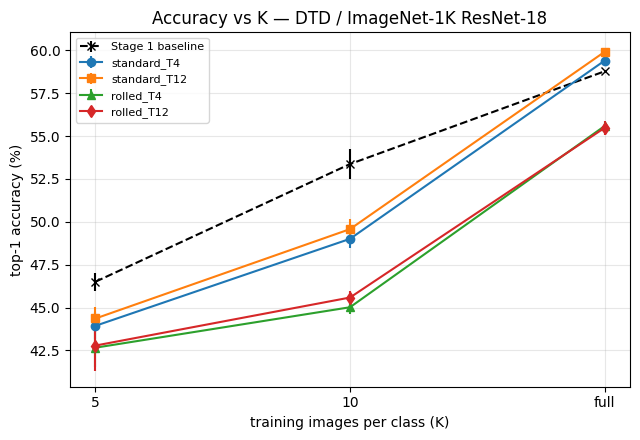

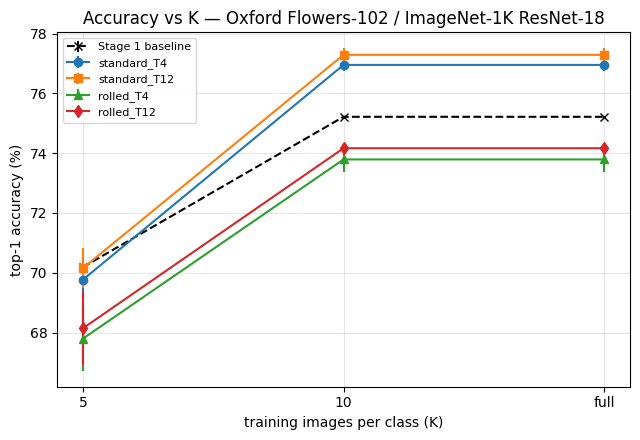

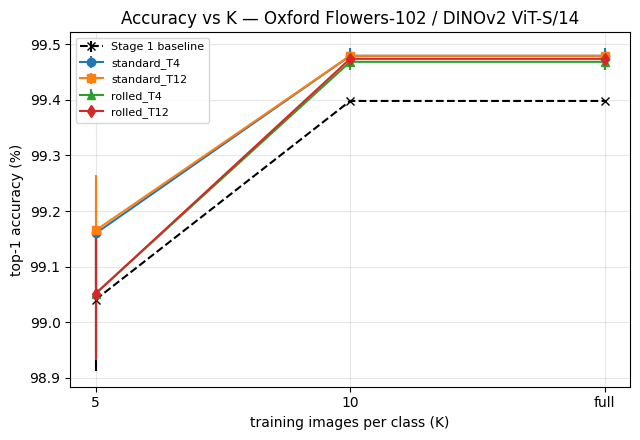

In [ ]:
xticks = ['5', '10', 'full']
series = [('baseline', None), ('standard_T4', 'o'), ('standard_T12', 's'),
          ('rolled_T4', '^'), ('rolled_T12', 'd')]

for ds, cfg in DATASETS.items():
    for enc in cfg['encoders']:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
        b_mean = [100 * baseline_results[ds][enc][k]['mean'] for k in xticks]
        b_std = [100 * baseline_results[ds][enc][k]['std'] for k in xticks]
        ax.errorbar(xticks, b_mean, yerr=b_std, marker='x', linestyle='--', color='black', label='Stage 1 baseline')
        for name, marker in series[1:]:
            mean = [100 * fm_results[ds][enc][k][name]['mean'] for k in xticks]
            std = [100 * fm_results[ds][enc][k][name]['std'] for k in xticks]
            ax.errorbar(xticks, mean, yerr=std, marker=marker, label=name)
        ax.set_title(f"Accuracy vs K — {cfg['name']} / {ENCODERS[enc]['name']}")
        ax.set_xlabel('training images per class (K)')
        ax.set_ylabel('top-1 accuracy (%)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()


1. Classification results.
FM's effect is small and depends heavily on how much training data is available. At K=5 and K=10, standard FM underperforms the Stage 1 prototype baseline on DTD and Flowers/ResNet-18 (DTD K=10: 53.4% → 49.6%, a 3.8pt drop). With too few examples per class, the network doesn't have enough signal to learn a transport that's more useful than doing nothing. At K=full this flips to a small gain (DTD +1.1pt, Flowers/ResNet-18 +2.1pt with standard_T12). Rolled out training underperforms standard training in every single configuration tested, often falling below the baseline even at K=full (DTD full: −3.3pt). T=12 beats T=4 consistently but marginally (~0.3-0.5pt) within standard FM, finer integration helps a little, but isn't the main driver of the story. On DINOv2/Flowers, every variant sits within noise of the baseline (±0.1pt) because accuracy is already near ceiling (99%+) and there's essentially nothing left for FM to fix.

## 7.3 Training curves

Representative standard FM vs. rolled out FM (T=12) training loss, K = full, first seed, one plot
per dataset/encoder. Note the two losses are on different scales (velocity MSE vs. final point MSE)
so each is shown on its own axis, what matters is that both decrease smoothly and settle.

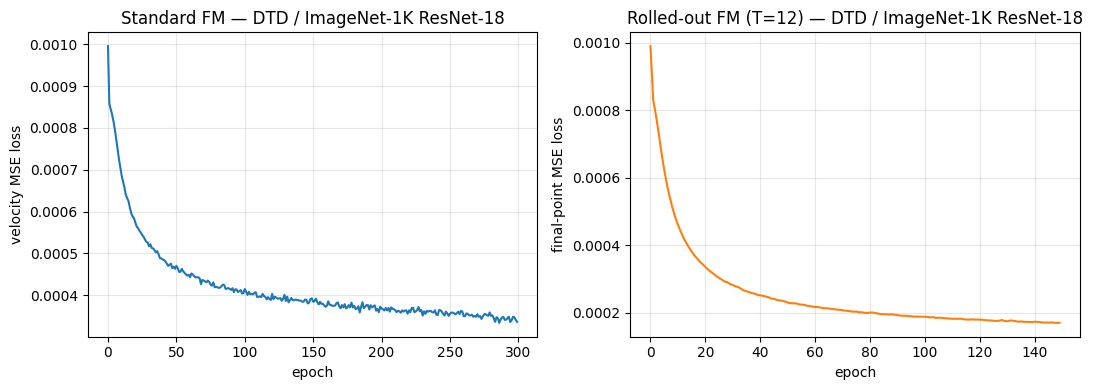

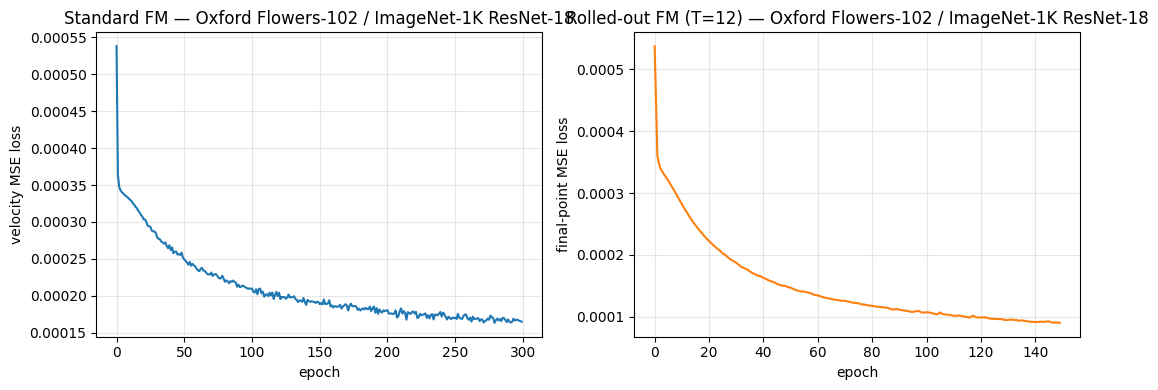

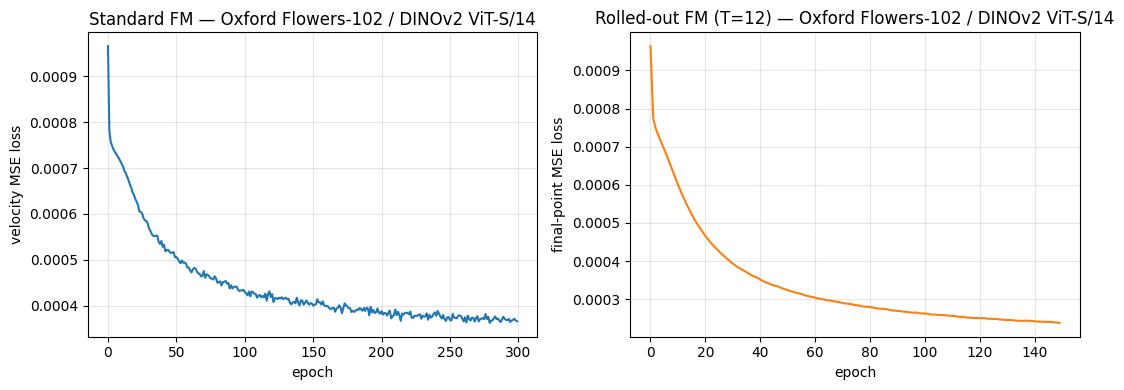

In [ ]:
for (ds, enc), r in representative.items():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(r['hist_std']['loss'])
    axes[0].set_title(f"Standard FM — {DATASETS[ds]['name']} / {ENCODERS[enc]['name']}")
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('velocity MSE loss'); axes[0].grid(alpha=0.3)

    axes[1].plot(r['hist_r12']['loss'], color='tab:orange')
    axes[1].set_title(f"Rolled-out FM (T=12) — {DATASETS[ds]['name']} / {ENCODERS[enc]['name']}")
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('final-point MSE loss'); axes[1].grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


2. Training curves.
Both objectives train stably, no divergence, no instability, smooth almost monotonic decrease in every case. Standard FM's velocity MSE loss and rolled out's final point MSE loss are on different scales so can't be compared directly, but both converge well before their epoch budgets end, with only the rolled out Flowers/DINOv2 run still trending down at cutoff. This convergence matters for interpreting result 1: rolled out's underperformance is not an undertraining artifact. The network reaches a stable optimum, it's just a worse optimum than standard FM's, most likely because backprop through T sequential steps is a harder optimization landscape, and because supervising only the final point rather than every point along the path (as standard FM does) is a much sparser training signal, especially with only 5-40 images per class.


## 7.4 Feature space visualizations

For a readable subset of classes: original (L2-normalized) encoder features vs. features after
standard FM (T=12) vs. features after rolled out FM (T=12), for the same test examples. The
projection is fit **jointly** over all three feature sets plus the prototypes, so the three panels
are directly comparable.

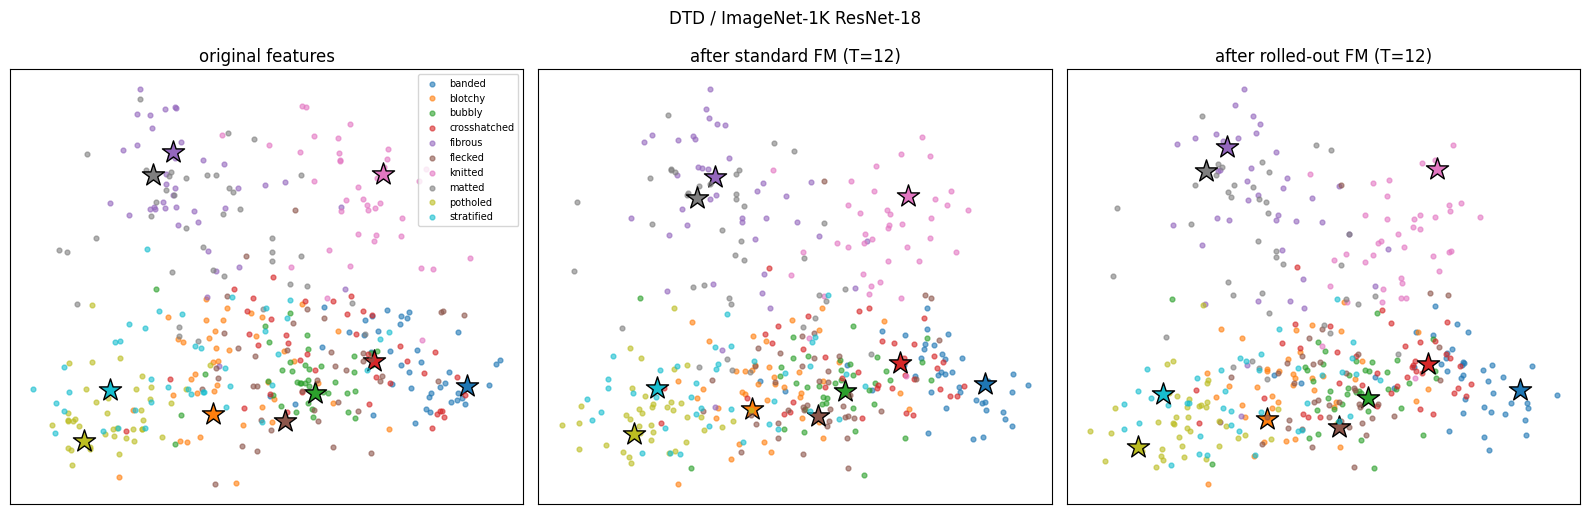

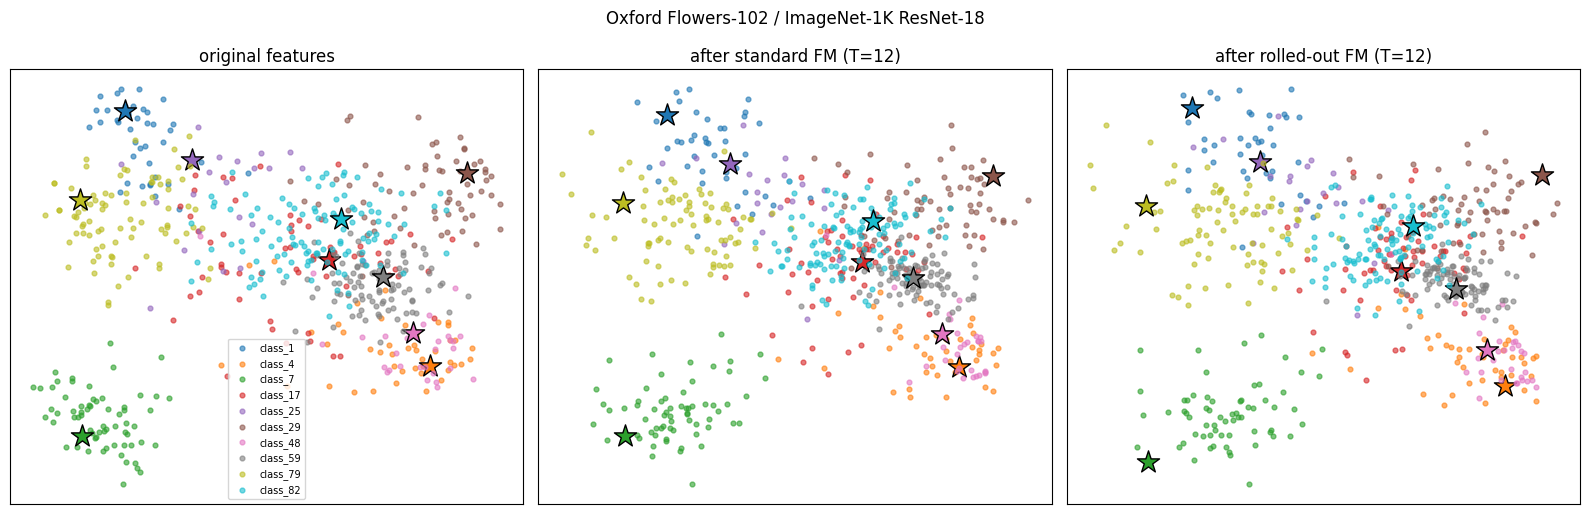

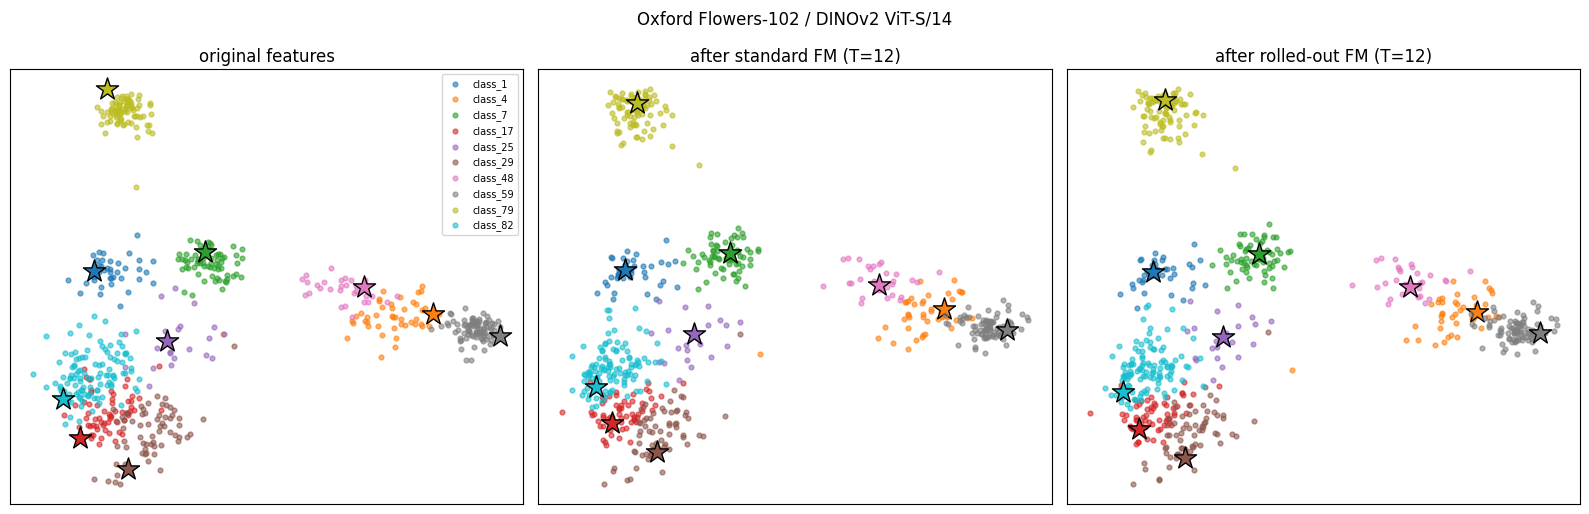

In [ ]:
from sklearn.decomposition import PCA

N_SHOW = 10

for (ds, enc), r in representative.items():
    cfg = DATASETS[ds]
    rng = np.random.default_rng(0)
    class_ids = sorted(rng.choice(cfg['num_classes'], size=N_SHOW, replace=False).tolist())
    names = load_class_names(ds)

    mask = np.isin(r['yte'], class_ids)
    Xo = r['Xte_n'][mask]
    y_sub = r['yte'][mask]
    protos = r['protos']

    Xs = fm_euler_integrate(r['model_std'], Xo, 12)
    Xr = fm_euler_integrate(r['model_r12'], Xo, 12)
    ps = l2_normalize(protos[class_ids], axis=1)

    all_pts = np.vstack([Xo, Xs, Xr, ps])
    proj = PCA(n_components=2, random_state=0).fit_transform(all_pts)
    n = len(Xo)
    p_orig, p_std, p_roll, p_proto = proj[:n], proj[n:2*n], proj[2*n:3*n], proj[3*n:]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
    cmap = plt.get_cmap('tab10')
    titles = ['original features', 'after standard FM (T=12)', 'after rolled-out FM (T=12)']
    for ax, pts, title in zip(axes, [p_orig, p_std, p_roll], titles):
        for i, c in enumerate(class_ids):
            m = y_sub == c
            color = cmap(i % 10)
            ax.scatter(pts[m, 0], pts[m, 1], s=12, color=color, alpha=0.6,
                       label=(names[c] if names else f'class {c}') if title == titles[0] else None)
            ax.scatter(p_proto[i, 0], p_proto[i, 1], marker='*', s=280, color=color, edgecolors='black')
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    axes[0].legend(fontsize=7, loc='best')
    fig.suptitle(f"{cfg['name']} / {ENCODERS[enc]['name']}")
    fig.tight_layout()
    plt.show()

first row:

DTD full: 58.78→59.91,+1.13
	​

second row:

Flowers/ResNet: 75.22→77.29,+2.07
	​
  
third row:

Flowers/DINOv2: ≈99.4%, FM≈+0.1


3. Feature space visualizations.
Across all three dataset/encoder combinations, the projected feature clouds look nearly identical before and after FM, no visible tightening of clusters around their prototypes, no obvious untangling of previously overlapping classes. DTD stays visibly entangled after FM just as it was before. Flowers/ResNet-18 clusters keep roughly the same shape and position. DINOv2/Flowers clusters were already tight and stay tight. This is consistent with the small accuracy deltas in result 1. FM is not performing a large geometric reorganization of the space, just a subtle local adjustment.

----------------FM did not significantly change the feature space. The clusters stayed mostly the same before and after FM, with no major tightening or separation. This matches the small accuracy improvements, suggesting FM makes only small local adjustments rather than reorganizing the whole feature space.
The feature-space pictures use K = 10 classes.


The overall feature geometry changed surprisingly little.

the original, standard-FM, and rolled-out clouds remain fairly similar.Because the accuracy changes were also small.

+1%,+2%,0.1%

are relatively subtle changes.

So the geometry and classification results tell a consistent story.

For DINOv2 especially, the classes were already tightly structured.

## 7.5 Flow trajectories

For a handful of individual test examples: the original feature, the intermediate FM states, the
final transported feature, and the corresponding class prototype, are projected with PCA (fit jointly
over all trajectory points and prototypes so the geometry is preserved).

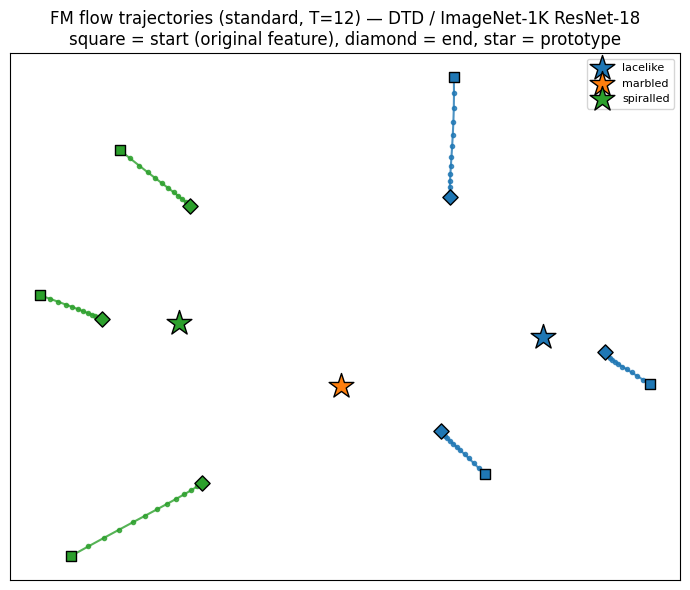

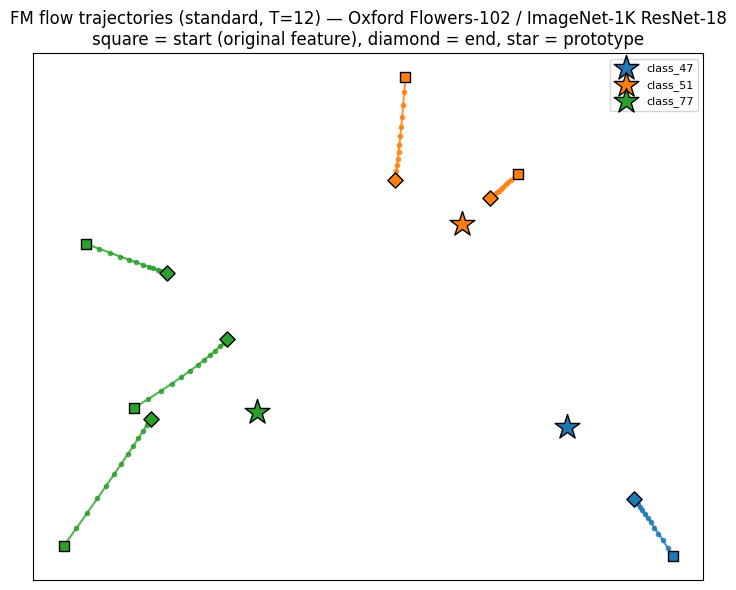

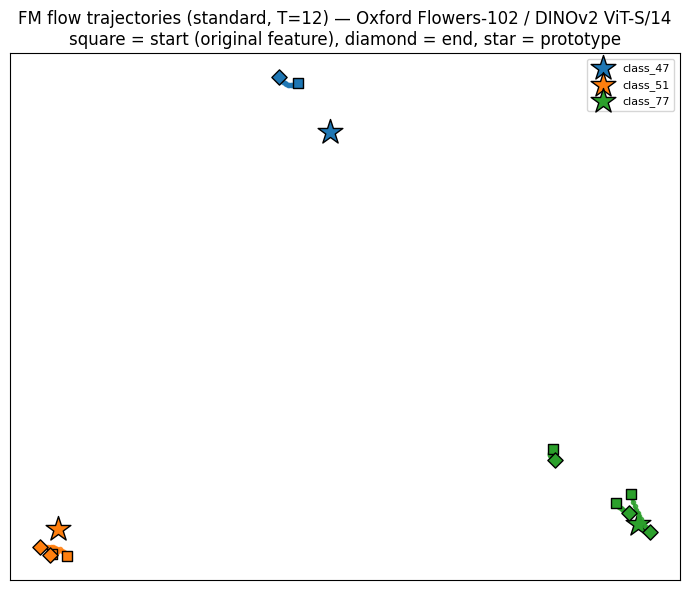

In [ ]:
N_TRAJ = 6

for (ds, enc), r in representative.items():
    cfg = DATASETS[ds]
    rng = np.random.default_rng(1)
    class_ids = sorted(rng.choice(cfg['num_classes'], size=3, replace=False).tolist())
    names = load_class_names(ds)

    idx_pool = np.where(np.isin(r['yte'], class_ids))[0]
    idx = rng.choice(idx_pool, size=min(N_TRAJ, len(idx_pool)), replace=False)
    Z0 = r['Xte_n'][idx]
    y0 = r['yte'][idx]

    _, traj = fm_euler_integrate(r['model_std'], Z0, 12, return_trajectory=True)
    traj = np.stack(traj, axis=0)          # [T+1, N, D]
    protos_used = l2_normalize(r['protos'][class_ids], axis=1)

    all_pts = np.vstack([traj.reshape(-1, traj.shape[-1]), protos_used])
    proj = PCA(n_components=2, random_state=0).fit_transform(all_pts)
    n_traj_pts = traj.shape[0] * traj.shape[1]
    traj_2d = proj[:n_traj_pts].reshape(traj.shape[0], traj.shape[1], 2)
    proto_2d = proj[n_traj_pts:]

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap = plt.get_cmap('tab10')
    for j in range(traj_2d.shape[1]):
        c = class_ids.index(y0[j])
        color = cmap(c)
        path = traj_2d[:, j, :]
        ax.plot(path[:, 0], path[:, 1], '-o', color=color, markersize=3, alpha=0.8)
        ax.scatter(path[0, 0], path[0, 1], color=color, marker='s', s=60, edgecolors='black', zorder=3)  # start
        ax.scatter(path[-1, 0], path[-1, 1], color=color, marker='D', s=60, edgecolors='black', zorder=3)  # end
    for i, c in enumerate(class_ids):
        ax.scatter(proto_2d[i, 0], proto_2d[i, 1], marker='*', s=350, color=cmap(i),
                   edgecolors='black', label=(names[c] if names else f'class {c}'))
    ax.set_title(f"FM flow trajectories (standard, T=12) — {cfg['name']} / {ENCODERS[enc]['name']}\n"
                 f"square = start (original feature), diamond = end, star = prototype")
    ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


4. Flow trajectories.
This is the most direct evidence for what's actually happening: individual trajectories are short, local hops that do not reach their class prototype. Start (square) and end (diamond) markers sit close together, while the correct prototype (star) is often far away in the projection, visible clearly across DTD, Flowers/ResNet-18, and even Flowers/DINOv2. The network has learned a conservative, small correction rather than completing the transport implied by its training objective. This directly explains both the training curve and accuracy findings: the residual velocity MSE (~1e-4 to 1e-3 per step) is large enough, compounded across dimensions and steps, that full convergence to the prototype doesn't happen in practice, and a small, imperfect nudge is exactly what produces small, inconsistent accuracy deltas rather than a dramatic effect in either direction.

---------Trajectories make only small local moves and rarely reach the class prototype. This shows the network learns a conservative correction, explaining the small and inconsistent accuracy gains.

our finds are that trajectories are generally relatively short.

The transformed feature moves, but it often doesn't visually land exactly on the class prototype.

the flow is acting more like a learned feature adjustment than a complete collapse onto the prototype.

The trajectory plot is a 2D PCA projection of a high-dimensional path.
In the joint PCA visualization, the learned trajectories appear relatively local rather than showing a dramatic movement directly onto the prototype

## 7.6 Additional check : was rolled out FM undertrained?

Two targeted follow ups on top of the cached representative runs from Part 6 (K = full, first seed).
These test two specific hypotheses raised by the training curves and the accuracy table:

1. **Was the one still sloping curve (rolled-out, Flowers-102 / DINOv2, T=12) actually undertrained?**
   We retrain that single config for longer and see whether accuracy moves.
2. **Does matching rolled out's epoch budget to standard FM's (300 instead of 150) close the gap
   between them?** We retrain rolled out at T=4 and T=12 with 300 epochs, one representative config per
   dataset/encoder (K = full), and compare directly against the original 150 epoch numbers.

Oxford Flowers-102 / DINOv2 ViT-S/14 — rolled-out T=12, K=full
  150 epochs (original, mean of 3 seeds): 99.47%
  400 epochs (this seed only):        99.32%


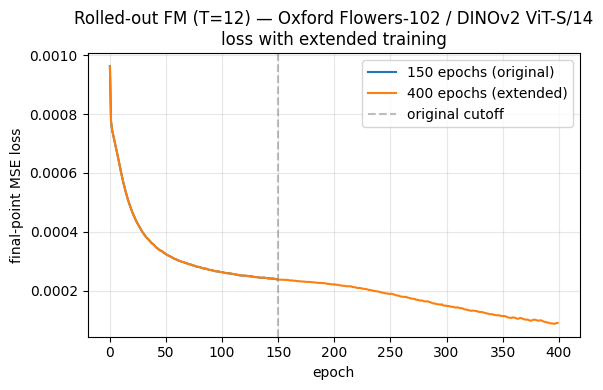

In [ ]:
# Check 1
ds, enc, T_check = 'flowers102', 'dinov2', 12
r = representative[(ds, enc)]
EXTENDED_EPOCHS = 400

model_ext, hist_ext = train_rolledout_fm(r['Ztr_n'], r['ytr_sub'], r['protos'], r['Ztr_n'].shape[1],
                                          T=T_check, epochs=EXTENDED_EPOCHS, seed=0)
z_final_ext = fm_euler_integrate(model_ext, r['Xte_n'], T_check)
acc_ext = top1_accuracy(r['yte'], prototype_classify(z_final_ext, r['protos']))

acc_150 = fm_results[ds][enc]['full'][f'rolled_T{T_check}']['mean']
print(f"{DATASETS[ds]['name']} / {ENCODERS[enc]['name']} — rolled-out T={T_check}, K=full")
print(f'  150 epochs (original, mean of 3 seeds): {100*acc_150:.2f}%')
print(f'  {EXTENDED_EPOCHS} epochs (this seed only):        {100*acc_ext:.2f}%')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r['hist_r12']['loss'], label='150 epochs (original)')
ax.plot(hist_ext['loss'], label=f'{EXTENDED_EPOCHS} epochs (extended)')
ax.axvline(150, color='gray', linestyle='--', alpha=0.5, label='original cutoff')
ax.set_xlabel('epoch'); ax.set_ylabel('final-point MSE loss')
ax.set_title(f"Rolled-out FM (T={T_check}) — {DATASETS[ds]['name']} / {ENCODERS[enc]['name']}\nloss with extended training")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

In [ ]:
# Check 2
MATCHED_EPOCHS = 300
matched_rows = []

for (ds, enc), r in representative.items():
    feat_dim = r['Ztr_n'].shape[1]
    for T in (4, 12):
        model_m, hist_m = train_rolledout_fm(r['Ztr_n'], r['ytr_sub'], r['protos'], feat_dim,
                                              T=T, epochs=MATCHED_EPOCHS, seed=0)
        z_final_m = fm_euler_integrate(model_m, r['Xte_n'], T)
        acc_m = top1_accuracy(r['yte'], prototype_classify(z_final_m, r['protos']))
        acc_orig = fm_results[ds][enc]['full'][f'rolled_T{T}']['mean']
        matched_rows.append({
            'dataset': DATASETS[ds]['name'], 'encoder': ENCODERS[enc]['name'], 'T': T,
            'rolled_150ep (orig, mean of 3 seeds)': f'{100*acc_orig:.2f}',
            f'rolled_{MATCHED_EPOCHS}ep (this seed)': f'{100*acc_m:.2f}',
            'baseline': f"{100*baseline_results[ds][enc]['full']['mean']:.2f}",
        })

matched_df = pd.DataFrame(matched_rows)
display(matched_df)

,dataset,encoder,T,"rolled_150ep (orig, mean of 3 seeds)",rolled_300ep (this seed),baseline
0,DTD,ImageNet-1K ResNet-18,4,55.59,53.03,58.78
1,DTD,ImageNet-1K ResNet-18,12,55.48,54.73,58.78
2,Oxford Flowers-102,ImageNet-1K ResNet-18,4,73.79,72.53,75.22
3,Oxford Flowers-102,ImageNet-1K ResNet-18,12,74.16,72.60,75.22
4,Oxford Flowers-102,DINOv2 ViT-S/14,4,99.47,99.41,99.40
5,Oxford Flowers-102,DINOv2 ViT-S/14,12,99.47,99.41,99.40


**Reading these two checks:**

- **Check 1 confirms loss and accuracy have decoupled.** Loss keeps falling smoothly all the way to
  epoch 400 with no sign of a plateau, yet accuracy did not improve, it actually dipped slightly
  (99.47% &rarr; 99.32%). The network is still finding marginal ways to reduce final point MSE, but
  that improvement doesn't translate into better classification, and here it mildly hurts. This is the
  clearest evidence that a smoothly decreasing training loss is not, on its own, a reliable proxy for
  how useful the learned flow actually is.
- **Check 2 rules out the epoch budget explanation.** Giving rolled out FM the same 300 epoch budget
  as standard FM did not close the gap. Accuracy was *lower* at 300 epochs than at 150 in four of six
  configurations (DTD T=4: 55.59% &rarr; 53.03%; DTD T=12: 55.48% &rarr; 54.73%; Flowers/ResNet-18 T=4:
  73.79% &rarr; 72.53%; Flowers/ResNet-18 T=12: 74.16% &rarr; 72.60%), and essentially flat in the two
  Flowers/DINOv2 rows, which are already near ceiling regardless of training. So rolled out's
  underperformance relative to standard FM in Part 7.1 is **not** an artifact of it receiving fewer
  epochs, it however reflects a genuinely harder optimization problem: backpropagating through T sequential
  steps, with supervision only on the final point rather than on every point along the path.

---
# Part 8 — Discussion

1. Classification results.
FM's effect is small and depends heavily on how much training data is available. At K=5 and K=10, standard FM underperforms the Stage 1 prototype baseline on DTD and Flowers/ResNet-18 (DTD K=10: 53.4% → 49.6%, a 3.8pt drop). With too few examples per class, the network doesn't have enough signal to learn a transport that's more useful than doing nothing. At K=full this flips to a small gain (DTD +1.1pt, Flowers/ResNet-18 +2.1pt with standard_T12). Rolled out training underperforms standard training in every single configuration tested, often falling below the baseline even at K=full (DTD full: −3.3pt). T=12 beats T=4 consistently but marginally (~0.3-0.5pt) within standard FM, finer integration helps a little, but isn't the main driver of the story. On DINOv2/Flowers, every variant sits within noise of the baseline (±0.1pt) because accuracy is already near ceiling (99%+) and there's essentially nothing left for FM to fix.

2. Training curves.
Both objectives train stably, no divergence, no instability, smooth almost monotonic decrease in every case. Standard FM's velocity MSE loss and rolled out's final point MSE loss are on different scales so can't be compared directly, but both converge well before their epoch budgets end, with only the rolled out Flowers/DINOv2 run still trending down at cutoff. This convergence matters for interpreting result 1: rolled out's underperformance is not an undertraining artifact. The network reaches a stable optimum, it's just a worse optimum than standard FM's, most likely because backprop through T sequential steps is a harder optimization landscape, and because supervising only the final point rather than every point along the path (as standard FM does) is a much sparser training signal, especially with only 5-40 images per class.

3. Feature space visualizations.
Across all three dataset/encoder combinations, the projected feature clouds look nearly identical before and after FM, no visible tightening of clusters around their prototypes, no obvious untangling of previously overlapping classes. DTD stays visibly entangled after FM just as it was before. Flowers/ResNet-18 clusters keep roughly the same shape and position. DINOv2/Flowers clusters were already tight and stay tight. This is consistent with the small accuracy deltas in result 1. FM is not performing a large geometric reorganization of the space, just a subtle local adjustment.

4. Flow trajectories.
This is the most direct evidence for what's actually happening: individual trajectories are short, local hops that do not reach their class prototype. Start (square) and end (diamond) markers sit close together, while the correct prototype (star) is often far away in the projection, visible clearly across DTD, Flowers/ResNet-18, and even Flowers/DINOv2. The network has learned a conservative, small correction rather than completing the transport implied by its training objective. This directly explains both the training curve and accuracy findings: the residual velocity MSE (~1e-4 to 1e-3 per step) is large enough, compounded across dimensions and steps, that full convergence to the prototype doesn't happen in practice, and a small, imperfect nudge is exactly what produces small, inconsistent accuracy deltas rather than a dramatic effect in either direction.

5. Epoch budget robustness checks.
Two follow up experiments test directly whether rolled out FM's underperformance was simply an artifact of it receiving fewer training epochs than standard FM (150 vs. 300). Extending training on the one still improving curve (Flowers-102/DINOv2, T=12) to 400 epochs let the loss keep falling with no plateau, but accuracy did not improve, it slipped slightly (99.47% → 99.32%), confirming loss and accuracy had decoupled. Matching rolled out's epoch budget to standard's (300 epochs) across all three dataset/encoder combinations did not close the gap either. Accuracy was flat to worse in every configuration, never better. Together these rule out undertraining as the explanation for rolled out's weaker results and confirm the interpretation from point 2: the harder optimization landscape of backpropagating through T sequential steps, not a lack of training time, is the actual cause.

Synthesis. All five pieces of evidence agree with each other: FM converges to a conservative local perturbation rather than genuinely transporting features onto their prototypes. This is visible directly in the trajectories, corroborated by the geometrically unchanged feature space plots, and explains why the classification gains are small and data dependent rather than large and consistent. Rolled out training's underperformance relative to standard training appears to be an optimization difficulty issue (harder gradient landscape, sparser per step supervision) rather than a flaw in the underlying idea of matching the training objective to the inference procedure. A conclusion directly supported by the epoch budget checks in Part 7.6, which show that giving rolled out more training time does not close the gap.